# Temporal-SatCLIP Fine-tuning Notebook

Experimental notebook for fine-tuning Temporal-SatCLIP on downstream tasks.

Currently only support NOAA GHCNd.

In [1]:
import pandas as pd
from main import SatCLIPLightningModule
import location_encoder as LE
from temporal_encoding import Fourier, Direct
from tqdm import tqdm
from matplotlib import pyplot as plt
import torch
import torch.nn as nn

In [2]:
# Load a pre-trained spatio-temporal SatCLIP encoder
# ckpt_path = '/home/leca5365/Documents/satclip/satclip/satclip_temporal_logs/satclip-s2-temporal-55k-temporalsplits-fixednormalizeddayofyear/satclip-fixed-normalized-day-of-year/checkpoints/last.ckpt'
ckpt_path = '/home/leca5365/Documents/satclip/satclip/satclip_temporal_logs/satclip-s2-satcliploss-100k/satclip-s2-satcliploss-100k/checkpoints/last-v2.ckpt'
# ckpt_path = '/home/leca5365/Documents/satclip/satclip/satclip_temporal_logs/satclip-s2-softloss-100k/satclip-s2-softloss-100k/checkpoints/last.ckpt'

lightning_model = SatCLIPLightningModule.load_from_checkpoint(ckpt_path)

lightning_model.eval()
spatiotemporal_enc = lightning_model.model.location
visual_enc = lightning_model.model.visual

using pretrained moco vit16
using loss function: satclip_loss
using temporal model: True


In [3]:
# Load the training GHCN dataset
ghcn_df_training = pd.read_csv('../notebooks/ghcn_2021_2023_temperature.csv')
print(len(ghcn_df_training))

# Load the testing GHCN dataset
ghcn_df_testing = pd.read_csv('../notebooks/ghcn_2024_2026_temperature.csv')
print(len(ghcn_df_testing))

26419496
17051878


In [4]:
# create MLP head for temperature prediction

class TemperaturePredictor(nn.Module):
    def __init__(self, location_encoder, embed_dim=256, hidden_dim=512):
        super(TemperaturePredictor, self).__init__()
        self.location_encoder = location_encoder
        self.fc1 = nn.Linear(embed_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1)  # Predict temperature

    def forward(self, coord):
        loc_emb = self.location_encoder(coord)
        x = torch.relu(self.fc1(loc_emb))
        temp_pred = self.fc2(x)
        return temp_pred
    
tp = TemperaturePredictor(spatiotemporal_enc)

tp.location_encoder.requires_grad_(False)

# Print trainable parameters
print("Trainable parameters:")
for name, param in tp.named_parameters():
    if param.requires_grad:
        print(name, param.shape)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
tp.to(device)
tp.double()

Trainable parameters:
fc1.weight torch.Size([512, 256])
fc1.bias torch.Size([512])
fc2.weight torch.Size([1, 512])
fc2.bias torch.Size([1])


TemperaturePredictor(
  (location_encoder): SpatioTemporalEncoder(
    (temporal_enc): Fourier()
    (pos_enc): SphericalHarmonics()
    (nnet): SirenNet(
      (layers): ModuleList(
        (0-1): 2 x Siren(
          (activation): Sine()
        )
      )
      (last_layer): Siren(
        (activation): Identity()
      )
    )
  )
  (fc1): Linear(in_features=256, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=1, bias=True)
)

In [5]:
import numpy as np
num_locations = 1000
random_location_ids = np.random.choice(ghcn_df_training['ID'].unique(), num_locations, replace=False) 
# print("Randomly selected location IDs for training:", random_location_ids)

In [6]:
# Subsample the dataset to a single location by ID for testing
# location_id = "USW00094728"  # Example location ID (New York Central Park)
# ghcn_df_subset = ghcn_df[ghcn_df["ID"] == location_id]
# len(ghcn_df_subset)

# Subsample the dataset to a random selection of location IDs for training
ghcn_df_subset = ghcn_df_training[ghcn_df_training['ID'].isin(random_location_ids)]

# ghcn_df_subset = ghcn_df_training.copy()  # Use the full dataset for training

In [7]:
test_all_df = ghcn_df_testing[(ghcn_df_testing["Element"]=="TMAX") & (ghcn_df_testing["QFlag"].isna())]
test_all_df['Date'] = pd.to_datetime(test_all_df['Date'], format="%Y%m%d")
test_all_df['DayOfYear'] = (test_all_df['Date'].dt.dayofyear - 1) / 364.0

/tmp/ipykernel_36445/3466551987.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_all_df['Date'] = pd.to_datetime(test_all_df['Date'], format="%Y%m%d")
/tmp/ipykernel_36445/3466551987.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_all_df['DayOfYear'] = (test_all_df['Date'].dt.dayofyear - 1) / 364.0


In [8]:
ghcn_test_subset_df = ghcn_df_testing[ghcn_df_testing['ID'].isin(random_location_ids)]
test_df = ghcn_test_subset_df[(ghcn_test_subset_df["Element"]=="TMAX") & (ghcn_test_subset_df["QFlag"].isna())]
test_df['Date'] = pd.to_datetime(test_df['Date'], format="%Y%m%d")
test_df['DayOfYear'] = (test_df['Date'].dt.dayofyear - 1) / 364.0

/tmp/ipykernel_36445/2714673626.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['Date'] = pd.to_datetime(test_df['Date'], format="%Y%m%d")
/tmp/ipykernel_36445/2714673626.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['DayOfYear'] = (test_df['Date'].dt.dayofyear - 1) / 364.0


In [9]:
# Create dataloader
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

from torch.utils.data import DataLoader, TensorDataset, random_split

# GHCN to day-of-year and TMAX
# dataset_df = ghcn_df[(ghcn_df["Element"]=="TMAX") & (ghcn_df["QFlag"].isna())]
dataset_df = ghcn_df_subset[(ghcn_df_subset["Element"]=="TMAX") & (ghcn_df_subset["QFlag"].isna())]
dataset_df['Date'] = pd.to_datetime(dataset_df['Date'], format="%Y%m%d")
dataset_df['DayOfYear'] = (dataset_df['Date'].dt.dayofyear - 1) / 364.0

# Prepare dataset
coords = torch.tensor(dataset_df[['Longitude', 'Latitude', 'DayOfYear']].values, dtype=torch.float32).double().to(device)
temperatures = torch.tensor(dataset_df['Value'].values, dtype=torch.float32).unsqueeze(1).double().to(device)

generator = torch.Generator().manual_seed(42)

dataset = TensorDataset(coords, temperatures)

train, val = random_split(TensorDataset(coords, temperatures), [int(0.8*len(coords)), len(coords) - int(0.8*len(coords))], generator=generator)

dataloader = DataLoader(train, batch_size=8192, shuffle=True)
dataloader_val = DataLoader(val, batch_size=8192, shuffle=False)

/tmp/ipykernel_36445/984973118.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset_df['Date'] = pd.to_datetime(dataset_df['Date'], format="%Y%m%d")
/tmp/ipykernel_36445/984973118.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset_df['DayOfYear'] = (dataset_df['Date'].dt.dayofyear - 1) / 364.0


In [10]:
# Temporal-only encoder + prediction head
# temporal_proj = LE.get_temporal_encoding("fourier", k=10)
# enc_head = LE.get_neural_network("siren", temporal_proj.embedding_dim, num_classes=256, dim_hidden=256, num_layers=2)
# temporal_encoder = LE.LocationEncoder(temporal_proj, enc_head)

# tp = TemperaturePredictor(temporal_encoder)

In [11]:
# Fine-tune the predictor head
from tqdm import tqdm

opt = torch.optim.AdamW(tp.parameters(), lr=1e-3, weight_decay=False)
criterion = nn.MSELoss()

num_epochs = 50
epoch_losses = []
epoch_val_losses = []

for epoch in tqdm(range(num_epochs)):
    tp.train()
    total_loss = 0

    for batch in tqdm(dataloader, desc="Training", leave=False):
        coords_batch, temp_batch = batch
        # coords_batch, temp_batch = coords_batch.to(device), temp_batch.to(device)
        opt.zero_grad()
        temp_pred = tp(coords_batch)  # Only use temporal part of the coordinates
        loss = criterion(temp_pred, temp_batch)
        loss.backward()
        opt.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(dataloader)
    # print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")
    epoch_losses.append(avg_loss)

    # Get validation error
    total_loss = 0
    for batch in dataloader_val:
        coords_batch, temp_batch = batch

        with torch.no_grad():
            temp_pred = tp(coords_batch)  # Only use temporal part of the coordinates
            loss = criterion(temp_pred, temp_batch)
            total_loss += loss.item()
    avg_val_loss = total_loss / len(dataloader_val)
    # print(f"Epoch {epoch+1}/{num_epochs}, Val Loss: {avg_val_loss:.4f}")
    epoch_val_losses.append(avg_val_loss)

100%|██████████| 50/50 [22:29<00:00, 27.00s/it]


In [12]:
torch.save(tp.state_dict(), "temperature_predictor.pth")

In [13]:
# Load the model if needed
tp.load_state_dict(torch.load("temperature_predictor.pth"))
tp.to(device)

TemperaturePredictor(
  (location_encoder): SpatioTemporalEncoder(
    (temporal_enc): Fourier()
    (pos_enc): SphericalHarmonics()
    (nnet): SirenNet(
      (layers): ModuleList(
        (0-1): 2 x Siren(
          (activation): Sine()
        )
      )
      (last_layer): Siren(
        (activation): Identity()
      )
    )
  )
  (fc1): Linear(in_features=256, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=1, bias=True)
)

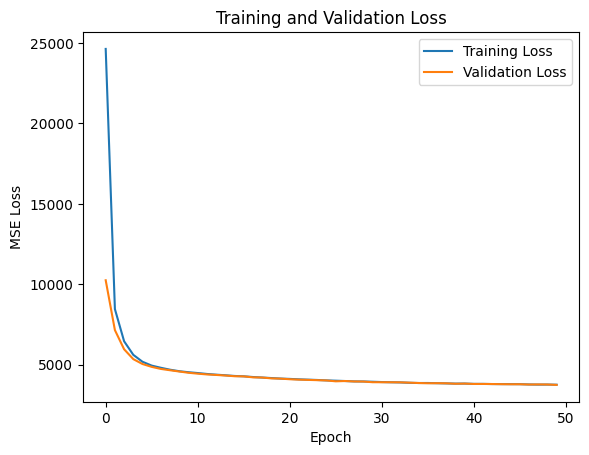

In [14]:
# Plot training and validation loss
plt.plot(epoch_losses, label='Training Loss')
plt.plot(epoch_val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

In [15]:
# Create a temporal encoder for the day of year
temporal_encoder = Fourier(k=10).to(device)

class TemperaturePredictorWithTemporal(nn.Module):
    def __init__(self, temporal_encoder, hidden_dim=512):
        super(TemperaturePredictorWithTemporal, self).__init__()
        self.temporal_encoder = temporal_encoder
        self.fc1 = nn.Linear(temporal_encoder.embedding_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1)  # Predict temperature

    def forward(self, coord):
        temporal_emb = self.temporal_encoder(coord[:, 2].unsqueeze(1))  # Use day of year for temporal encoding
        x = torch.relu(self.fc1(temporal_emb))
        temp_pred = self.fc2(x)
        return temp_pred
    
tp_temporal = TemperaturePredictorWithTemporal(temporal_encoder)

In [16]:
class TemperaturePredictorHead(nn.Module):
    def __init__(self, input_dim=3, hidden_dim=512):
        super(TemperaturePredictorHead, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1)  # Predict temperature

    def forward(self, input):
        x = torch.relu(self.fc1(input))
        temp_pred = self.fc2(x)
        return temp_pred

In [17]:
# Fine-tune the predictor head
from tqdm import tqdm

# tph = TemperaturePredictorHead(input_dim=3, hidden_dim=128)
tph = TemperaturePredictorWithTemporal(temporal_encoder)

for param in tph.parameters():
    param.requires_grad = True

opt = torch.optim.AdamW(tph.parameters(), lr=1e-3, weight_decay=False)
criterion = nn.MSELoss()

tph.to(device)
tph.double()

num_epochs = 100
for epoch in tqdm(range(num_epochs), desc="Epochs"):
    tph.train()
    total_loss = 0

    for batch in tqdm(dataloader, leave=False, desc="Batches"):
        coords_batch, temp_batch = batch
        # coords_batch, temp_batch = coords_batch.to(device), temp_batch.to(device)
        opt.zero_grad()
        temp_pred = tph(coords_batch)
        loss = criterion(temp_pred, temp_batch)
        loss.backward()
        opt.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(dataloader)
    # print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")

Epochs: 100%|██████████| 100/100 [05:51<00:00,  3.52s/it]


In [18]:
dataset_df[['ID', 'Name', 'Latitude', 'Longitude']][1000:1100]

,ID,Name,Latitude,Longitude
28471,UKE00105871,SLAPTON,50.2917,-3.6508
28479,UKE00105877,STORMONT CASTLE,54.6031,-5.8289
28513,RSM00022619,PADANY,63.2700,33.4200
28517,RSM00022648,TURCASOVO,63.1170,39.2330
28536,RSM00022854,NJANDOMA,61.7000,40.2000
...,...,...,...,...
31101,FIE00142226,HELSINKI KUMPULA,60.2028,24.9642
31118,FI000000304,HELSINKI KAISANIEMI AWS,60.1667,24.9500
31175,EN000026249,VORU,57.8458,27.0192
31177,ENE00100914,VILSANDI,58.3831,21.8153


In [19]:
tph.temporal_encoder(torch.tensor([[1.0], [182.0], [365.0]], dtype=torch.float32).to(device)).shape

torch.Size([3, 20])

In [22]:
# Clear GPU memory
torch.cuda.empty_cache()

609490
tensor([[-124.4000,   49.3333,    0.0000],
        [-124.4333,   49.4833,    0.0000],
        [-124.5000,   49.8333,    0.0000],
        ...,
        [ -98.8797,   36.5758,    0.1264],
        [ -80.2058,   40.5489,    0.1264],
        [ -85.1258,   36.5808,    0.1264]], device='cuda:0',
       dtype=torch.float64)
tensor(-339.0501, device='cuda:0', dtype=torch.float64)
Predicted Mean: 16.519991225181407
True Mean: 17.000213457152704


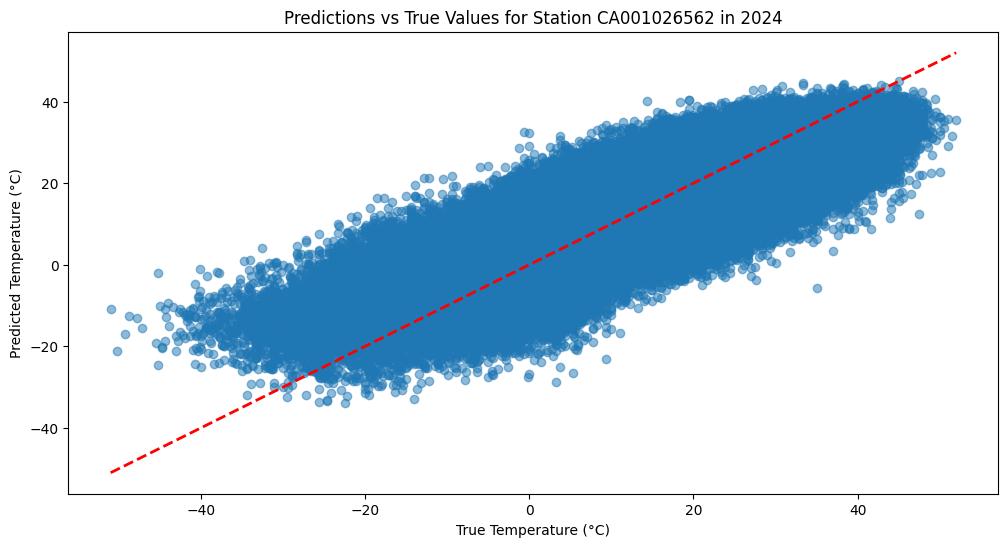

/tmp/ipykernel_36445/1904472746.py:46: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/home/leca5365/miniconda3/envs/satclip313/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


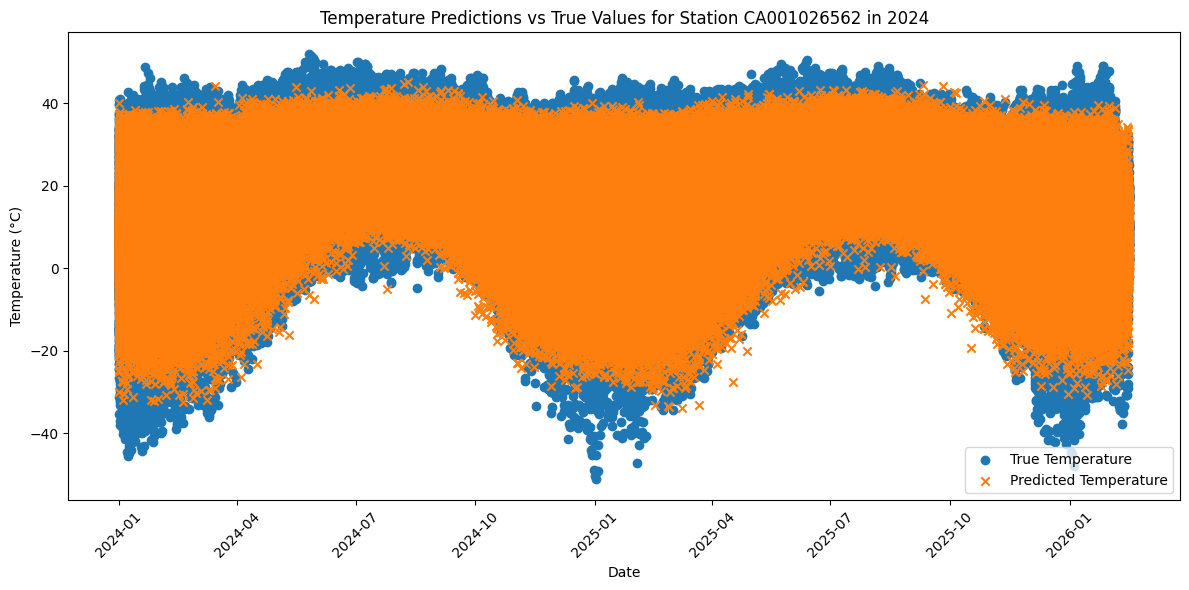

In [23]:
# Plot the predictions vs true values for a given location in 2023
import matplotlib.pyplot as plt

# Select a specific location (e.g., station ID 0000012345)
# selected_station = dataset_df[dataset_df['ID'] == 'RSM00032121']
# selected_station = dataset_df[dataset_df['ID'] == location_id]
# selected_station = test_df[test_df['ID'].isin([random_location_ids[7]])]
# selected_station = test_df
# selected_station = test_all_df
more_random_location_ids = np.random.choice(test_all_df['ID'].unique(), 1000, replace=False)
selected_station = test_all_df[test_all_df['ID'].isin(more_random_location_ids)]
print(len(selected_station))

# Get predictions for this station
coords_selected = torch.tensor(selected_station[['Longitude', 'Latitude', 'DayOfYear']].values, dtype=torch.float32).double().to(device)
print(coords_selected)
with torch.no_grad():
    # pred_selected = tph(coords_selected)
    pred_selected = tp(coords_selected)  # Only use temporal part of the coordinates
    print(pred_selected.min())

# Convert to numpy for plotting
print("Predicted Mean:", pred_selected.mean().item() / 10.0)
print("True Mean:", selected_station['Value'].mean() / 10.0)
pred_selected_np = pred_selected.cpu().numpy().flatten() / 10.0  # Convert from tenths of degrees C to degrees C
true_values_np = selected_station['Value'].values / 10.0  # Convert from tenths of degrees C to degrees C

# Plot predictions vs true values
plt.figure(figsize=(12, 6))
plt.scatter(true_values_np, pred_selected_np, alpha=0.5)
plt.plot([true_values_np.min(), true_values_np.max()], [true_values_np.min(), true_values_np.max()], 'r--', lw=2)
plt.xlabel('True Temperature (°C)')
plt.ylabel('Predicted Temperature (°C)')
plt.title(f'Predictions vs True Values for Station {selected_station["ID"].iloc[0]} in {selected_station["Date"].dt.year.iloc[0]}')
plt.show()

# Plot predictions and true values over time for the selected station
plt.figure(figsize=(12, 6))
plt.scatter(selected_station['Date'], true_values_np, label='True Temperature', marker='o')
plt.scatter(selected_station['Date'], pred_selected_np, label='Predicted Temperature', marker='x')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.title(f'Temperature Predictions vs True Values for Station {selected_station["ID"].iloc[0]} in {selected_station["Date"].dt.year.iloc[0]}')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
print(coords_selected.shape)
print(pred_selected.shape)
print(true_values_np.shape)

torch.Size([622726, 3])
torch.Size([622726, 1])
(622726,)


In [24]:
# Create GIF of predictions over time for all stations on Basemap (cyl) and another GIF of true values over time for all stations on Basemap (cyl), collect by month

from mpl_toolkits.basemap import Basemap
from mpl_toolkits.axes_grid1 import make_axes_locatable

from PIL import Image
import io
frames = []

temp_min = min(pred_selected_np.min(), true_values_np.min())
temp_max = max(pred_selected_np.max(), true_values_np.max())

for doy in tqdm(np.linspace(0, 1, 12)):  # Loop over months
    fig, ax = plt.subplots(2,1, figsize=(20, 10))

    # Plot predictions
    m = Basemap(projection='cyl', resolution='c', ax=ax[0])
    m.drawcoastlines()

    # Land mask
    t_coords_idx = np.abs(coords_selected[:, 2].cpu().numpy() - doy) < 30/364  # Within 30 days of doy
    t_coords = coords_selected[t_coords_idx][:, :2].cpu().numpy()
    t_preds = pred_selected[t_coords_idx].cpu().numpy() / 10.0  # Convert from tenths of degrees C to degrees C

    sc0 = ax[0].scatter(t_coords[:, 0], t_coords[:, 1], s=10, c=t_preds, cmap='coolwarm', label="Location", vmin=temp_min, vmax=temp_max)
    ax[0].set_title(f"Predicted Temps | Day of Year: {doy*364:.0f}")
    fig.colorbar(sc0, label='Temperature (°C)')


    # Plot true values
    m = Basemap(projection='cyl', resolution='c', ax=ax[1])
    m.drawcoastlines()

    # Land mask
    t_coords_idx = np.abs(coords_selected[:, 2].cpu().numpy() - doy) < 30/364  # Within 30 days of doy
    t_coords = coords_selected[t_coords_idx][:, :2].cpu().numpy()
    t_preds = true_values_np[t_coords_idx]  # Use true values instead of predictions

    sc1 = ax[1].scatter(t_coords[:, 0], t_coords[:, 1], s=10, c=t_preds, cmap='coolwarm', label="Location", vmin=temp_min, vmax=temp_max)

    ax[1].set_title(f"True Temps | Day of Year: {doy*364:.0f}")

    fig.colorbar(sc1, label='Temperature (°C)')

    buf = io.BytesIO()
    fig.savefig(buf, format='png')
    buf.seek(0)
    frames.append(Image.open(buf))

    plt.close(fig)

frames[0].save('NOAA-GHCNd-finetuned-predictions-satcliploss.gif', format='GIF', append_images=frames[1:], save_all=True, duration=500, loop=0)

100%|██████████| 12/12 [00:18<00:00,  1.54s/it]


In [ ]:
# Spatial cross validation

# Given 4-degree or 8-degree spatial splits, train on 3 splits and test on the held-out split, repeat for all splits, and average results.
degree_splits = 4
lon_bins = np.arange(-180, 180 + degree_splits, degree_splits)
lat_bins = np.arange(-90, 90 + degree_splits, degree_splits)

